In [ ]:
!nvidia-smi

In [ ]:
!python --version
!pip --version

In [ ]:
import sys
import sklearn

import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf



plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [ ]:
import tensorflow as tf
print(tf.__version__)


# deepfake-faces Dataset

## **Data Visualization**

In [3]:
import tensorflow as tf
import transformers as T
print(tf.__version__)
print(T.__version__)

2.16.1
4.44.0


In [ ]:
import os
# dfdc faces
def get_data():
#     return pd.read_csv('/kaggle/input/celebsv2-faces-224/CelebsV2_Faces_224/metadata.csv')
    return pd.read_csv('/kaggle/input/shrey-faces-dataset/CustomDataset/meta.csv')
        
    


In [ ]:
meta=get_data()
meta

In [ ]:
meta.shape #95634


In [ ]:
len(meta[meta.label=='FAKE']),len(meta[meta.label=='REAL'])

In [ ]:
real_df = meta[meta["label"] == "REAL"]
fake_df = meta[meta["label"] == "FAKE"]
# sample_size = 8000

real_df = real_df.sample(40, random_state=42)
fake_df = fake_df.sample(60, random_state=42)

sample_meta = pd.concat([real_df, fake_df])
len(sample_meta)

In [ ]:
from sklearn.model_selection import train_test_split

Train_set, Test_set = train_test_split(sample_meta,test_size=0.2,random_state=42,stratify=sample_meta['label'])
Train_set, Val_set  = train_test_split(Train_set,test_size=0.3,random_state=42,stratify=Train_set['label'])

In [ ]:
Test_set

In [ ]:
plt.figure(figsize=(15,15))
for cur,i in enumerate(Test_set.index):
    plt.subplot(5,5,cur+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    img = cv2.imread('/kaggle/input/shrey-faces-dataset/CustomDataset/'+Test_set.loc[i,'name'][:-4]+'.jpg')
#     print(img)
    img = cv2.resize(img,(224,224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
#     plt.imshow(cv2.imread('../input/deepfake-faces/faces_224/'+Test_set.loc[i,'videoname'][:-4]+'.jpg'))
#     plt.imshow(cv2.imread('../input/shrey-faces-dataset/CustomDataset/'+Test_set.loc[i,'name'][:-4]+'.jpg'))

    
    if(Test_set.loc[i,'label']=='FAKE'):
        plt.xlabel('FAKE Image')
    else:
        plt.xlabel('REAL Image')
        
plt.show()

## **Custom CNN Architecture**

In [ ]:
def retreive_dataset(set_name):
    images,labels=[],[]
    def imgResize(img,width,height):
        imgResize = cv2.resize(img,(width,height))
        return imgResize
    
    for (img, imclass) in zip(set_name['name'], set_name['label']):
        img = cv2.imread('/kaggle/input/shrey-faces-dataset/CustomDataset/'+img[:-4]+'.jpg')
#         img = cv2.imread('../input/shrey-faces-dataset/CustomDataset/'+img[:-4]+'.jpg')
        img = imgResize(img, 224,224) 
        images.append(img)
        if(imclass=='FAKE'):
            labels.append(1)
        else:
            labels.append(0)
    
    return np.array(images),np.array(labels)

In [ ]:
X_train,y_train=retreive_dataset(Train_set)
X_val,y_val=retreive_dataset(Val_set)
X_test,y_test=retreive_dataset(Test_set)

In [ ]:
from functools import partial
import tensorflow as tf

tf.random.set_seed(42) 
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, padding="same",
                        activation="relu", kernel_initializer="he_normal")

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[224, 224, 3]),  # Use Input layer with shape
    DefaultConv2D(filters=64, kernel_size=7),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=64, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=1, activation="sigmoid")
])

In [ ]:
# from tensorflow.keras.utils import plot_model

# plot_model(model,show_shapes=True, show_layer_names=True)

In [ ]:
model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.summary()

In [ ]:
history = model.fit(X_train, y_train, epochs=5,batch_size=64,
                    validation_data=(X_val, y_val))

In [ ]:
# Extract metrics
epoch_data = {
    'Epoch': list(range(1, len(history.history['accuracy']) + 1)),
    'Train Accuracy': history.history['accuracy'],
    'Train Loss': history.history['loss'],
    'Validation Accuracy': history.history['val_accuracy'],
    'Validation Loss': history.history['val_loss']
}

# Create DataFrame
df = pd.DataFrame(epoch_data)

# Display the table
print(df)

In [ ]:
# Assuming 'model' is your Keras model
model.save('DFDC_CNN.keras')


In [ ]:
# Load the model
model = keras.models.load_model("/kaggle/input/deepfake_models/keras/deepfake_models/2/my_model_Xception.h5")


In [ ]:
history = model.history
print(history.history)

In [ ]:
score = model.evaluate(X_test, y_test)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

# Assuming you have predictions (y_pred) from your model
y_pred = model.predict(X_test)

# Assuming y_pred is a probability score, you may need to convert it to binary predictions
y_pred_binary = (y_pred > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred_binary)
print(f'Accuracy: {accuracy}')

f1 = f1_score(y_test, y_pred_binary)
print(f'F1 Score: {f1}')

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_binary)
print('Confusion Matrix:')
print(conf_matrix)

In [ ]:
!pip install seaborn

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming y_test and y_pred_binary are defined

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_binary)

# Plot confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Real', 'Fake'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# plot model performance
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(history.epoch) + 1)

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Set')
plt.plot(epochs_range, val_acc, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Set')
plt.plot(epochs_range, val_loss, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.tight_layout()
plt.show()

In [ ]:
train_set_raw=tf.data.Dataset.from_tensor_slices((X_train,y_train))
valid_set_raw=tf.data.Dataset.from_tensor_slices((X_val,y_val))
test_set_raw=tf.data.Dataset.from_tensor_slices((X_test,y_test))

 **Xception**

In [ ]:
tf.keras.backend.clear_session()  # extra code – resets layer name counter

batch_size = 32
preprocess = tf.keras.applications.convnext.preprocess_input
train_set = train_set_raw.map(lambda X, y: (preprocess(tf.cast(X, tf.float32)), y))
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(lambda X, y: (preprocess(tf.cast(X, tf.float32)), y)).batch(batch_size)
test_set = test_set_raw.map(lambda X, y: (preprocess(tf.cast(X, tf.float32)), y)).batch(batch_size)

In [ ]:
# extra code – displays the first 9 images in the first batch of valid_set

plt.figure(figsize=(12, 12))
for X_batch, y_batch in test_set.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow((X_batch[index] + 1) / 2)  # rescale to 0–1 for imshow()
        if(y_batch[index]==1):
            classt='FAKE'
        else:
            classt='REAL'
        plt.title(f"Class: {classt}")
        plt.axis("off")

plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

In [ ]:
# extra code – displays the same first 9 images, after augmentation

plt.figure(figsize=(12, 12))
for X_batch, y_batch in test_set.take(1):
    X_batch_augmented = data_augmentation(X_batch, training=True)
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        # We must rescale the images to the 0-1 range for imshow(), and also
        # clip the result to that range, because data augmentation may
        # make some values go out of bounds (e.g., RandomContrast in this case).
        plt.imshow(np.clip((X_batch_augmented[index] + 1) / 2, 0, 1))
        if(y_batch[index]==1):
            classt='FAKE'
        else:
            classt='REAL'
        plt.title(f"Class: {classt}")
        plt.axis("off")

plt.show()

In [ ]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
# base_model = tf.keras.applications.xception.Xception(weights="imagenet",include_top=False)
# base_model = tf.keras.applications.ResNet50(weights="imagenet", include_top=False)

# base_model = tf.keras.applications.InceptionV3(weights='imagenet', include_top=False)

# base_model = tf.keras.applications.DenseNet121(weights='imagenet', include_top=False)
base_model = tf.keras.applications.ConvNeXtBase(weights="imagenet",include_top=False)

avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(1, activation="sigmoid")(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=output)

for layer in base_model.layers:
    layer.trainable = False

In [ ]:
for layer in base_model.layers[-100:]:
    layer.trainable = True

In [ ]:
len(base_model.layers)

In [ ]:
model.summary()

In [ ]:

    
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model.compile(loss="binary_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [ ]:

history = model.fit(train_set, validation_data=valid_set, epochs=3)

In [ ]:
model.save("dfdc_Xception.h5")

## MACs and FLOPs

In [ ]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops(model, input_shape):
    # Convert Keras model to ConcreteFunction
    concrete_func = tf.function(model).get_concrete_function(tf.TensorSpec(input_shape, tf.float32))
    
    # Convert ConcreteFunction to a frozen graph
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)
    
    # Create a session to run the frozen graph
    with tf.compat.v1.Session(graph=tf.Graph()) as sess:
        tf.import_graph_def(graph_def, name="")
        graph = tf.compat.v1.get_default_graph()
        
        # Calculate FLOPs using TensorFlow profiler
        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
        flops = tf.compat.v1.profiler.profile(graph=graph, run_meta=run_meta, cmd='op', options=opts)
        
    return flops.total_float_ops


In [ ]:
# Define input shape
input_shape = (1, 224, 224,3 )
# Calculate FLOPs
flops = get_flops(model, input_shape)
macs = flops // 2  # MACs is half the FLOPs for Conv2D

print(f"MACs: {macs}")
print(f"FLOPs: {flops}")

In [ ]:
print(f"MACs: {macs}")
print(f"FLOPs: {flops}")

## Data import

In [1]:
import sys
import sklearn

import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [10]:
import tensorflow as tf
print(tf.__version__)
# Check if a GPU is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set memory growth to prevent TensorFlow from allocating all memory at once
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is available and will be used.")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(f"Error: {e}")
else:
    print("GPU is not available, running on CPU.")

tf.test.is_gpu_available()

2.16.1
GPU is available and will be used.


True

In [3]:
import tensorflow as tf
seed_value = 42
tf.random.set_seed(seed_value)
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # TPU detection
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print("TPU is available and will be used.")
except ValueError:
    print("TPU is not available, using GPU or CPU.")

TPU is not available, using GPU or CPU.


In [11]:
import os

print(os.getcwd())
# dfdc faces
def get_data():
    return pd.read_csv('/kaggle/input/deepfake-faces/metadata.csv')
#     return pd.read_csv('/kaggle/input/shrey-faces-dataset/CustomDataset/meta.csv')
#     return pd.read_csv('/kaggle/input/celebsv2-faces-224/CelebsV2_Faces_224/metadata.csv')
    
        
    
get_data()

/kaggle/working


,videoname,original_width,original_height,label,original
0,aznyksihgl.mp4,129,129,FAKE,xnojggkrxt.mp4
1,gkwmalrvcj.mp4,129,129,FAKE,hqqmtxvbjj.mp4
2,lxnqzocgaq.mp4,223,217,FAKE,xjzkfqddyk.mp4
3,itsbtrrelv.mp4,186,186,FAKE,kqvepwqxfe.mp4
4,ddvgrczjno.mp4,155,155,FAKE,pluadmqqta.mp4
...,...,...,...,...,...
95629,rqcsjlsmiz.mp4,129,129,FAKE,pbsccacgff.mp4
95630,xjmnerypjf.mp4,90,90,FAKE,qrjydgidga.mp4
95631,hnewpzhihy.mp4,75,75,FAKE,vabhbfiifl.mp4
95632,okbarlnmwm.mp4,268,267,FAKE,uqaaspbgtz.mp4


In [6]:
# #modification for ff++
# meta = get_data()
# Name = [ i.split('/')[1] for i in meta["Name"]]
# meta["Name"] = Name
# meta

In [12]:
meta = get_data()
real_df = meta[meta["label"] == "REAL"]

fake_df = meta[meta["label"] == "FAKE"]
# sample_size = 8000

real_df = real_df.sample(8000, random_state=42)
fake_df = fake_df.sample(8000, random_state=42)

sample_meta = pd.concat([real_df, fake_df])


In [13]:
import cv2
import numpy as np
def retreive_dataset(set_name):
    images,labels=[],[]
    def imgResize(img,width,height):
        imgResize = cv2.resize(img,(width,height))
        return imgResize
    
    for (img, imclass) in zip(set_name['videoname'], set_name['label']):
#         img = cv2.imread('/kaggle/input/ff-face-224/FF++_Faces_224/FF++_Faces_224/'+img[:-4]+'.jpg')
#         img = cv2.imread('/kaggle/input/celebsv2-faces-224/CelebsV2_Faces_224/CelebsV2_Faces_224/'+img[:-4]+'.jpg')
        img = cv2.imread('../input/deepfake-faces/faces_224/'+img[:-4]+'.jpg')
#         img = cv2.imread('../input/shrey-faces-dataset/CustomDataset/'+img[:-4]+'.jpg')
#         img = imgResize(img, 224,224) 
        images.append(img)
        if(imclass=='FAKE'):
            labels.append(1)
        else:
            labels.append(0)
    print("Done")
    
    return np.array(images),np.array(labels)

In [14]:
from sklearn.model_selection import train_test_split

Train_set, Test_set = train_test_split(sample_meta,test_size=0.2,random_state=42,stratify=sample_meta['label'])
Train_set, Val_set  = train_test_split(Train_set,test_size=0.3,random_state=42,stratify=Train_set['label'])

In [15]:
X_train,y_train=retreive_dataset(Train_set)
X_val,y_val=retreive_dataset(Val_set)
X_test,y_test=retreive_dataset(Test_set)

Done
Done
Done


In [19]:

train_set_raw=tf.data.Dataset.from_tensor_slices((X_train,y_train))
valid_set_raw=tf.data.Dataset.from_tensor_slices((X_val,y_val))
test_set_raw=tf.data.Dataset.from_tensor_slices((X_test,y_test))

In [17]:
train_set_raw

<_TensorSliceDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

## pretrain model

In [20]:
tf.keras.backend.clear_session()  # extra code – resets layer name counter

batch_size = 32
preprocess = tf.keras.applications.convnext.preprocess_input
train_set = train_set_raw.map(lambda X, y: (preprocess(tf.cast(X, tf.float32)), y))
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(lambda X, y: (preprocess(tf.cast(X, tf.float32)), y)).batch(batch_size)
test_set = test_set_raw.map(lambda X, y: (preprocess(tf.cast(X, tf.float32)), y)).batch(batch_size)

In [ ]:
plt.figure(figsize=(12, 12))
for X_batch, y_batch in train_set.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        img = (X_batch[index].numpy())
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img /np.max(img)) # rescale to 0–1 for imshow()
        if(y_batch[index]==1):
            classt='FAKE'
        else:
            classt='REAL'
        plt.title(f"Class: {classt}")
        plt.axis("off")

plt.show()

In [ ]:
tf.random.set_seed(42) 
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

In [ ]:
# extra code – displays the same first 9 images, after augmentation

plt.figure(figsize=(12, 12))
for X_batch, y_batch in train_set.take(1):
    X_batch_augmented = data_augmentation(X_batch, training=True)
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        img = (X_batch_augmented[index].numpy())
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img /np.max(img)) # rescale to 0–1 for imshow()
        
        if(y_batch[index]==1):
            classt='FAKE'
        else:
            classt='REAL'
        plt.title(f"Class: {classt}")
        plt.axis("off")

plt.show()

In [21]:
tf.random.set_seed(42)  # Ensures reproducibility

tf.keras.backend.clear_session()
# Ensures reproducibility


base_model = tf.keras.applications.ConvNeXtBase(weights="imagenet", include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(1, activation="sigmoid")(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=output)
for layer in base_model.layers:
    layer.trainable = False

350926856/350926856 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [11]:

    
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(loss="binary_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [12]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger

model_name = "dfdc_ConvNeXt"

checkpoint_callback = ModelCheckpoint(
    filepath='best_model.keras',  # Path to save the model
    monitor='val_accuracy',        # yMetric to monitor
    save_best_only=True,       # Save only the best model
    save_weights_only=False,   # Save the entire model, not just weights
    mode='max',                # Mode to minimize the monitored metric
    verbose=1                  # Verbosity mode
)
csv_logger = CSVLogger(model_name+'.csv',append = True)

callbacks = [checkpoint_callback,csv_logger]

In [13]:


history = model.fit(train_set, validation_data=valid_set, epochs=10, callbacks= callbacks)


Epoch 1/10


I0000 00:00:1725957829.686033     105 service.cc:145] XLA service 0x7bfd68111ab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1725957829.686232     105 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1725957829.686241     105 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1725957845.205869     164 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_66', 1300 bytes spill stores, 1284 bytes spill loads

I0000 00:00:1725957846.671203     165 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_12', 1032 bytes spill stores, 1032 bytes spill loads

I0000 00:00:1725957851.834405     105 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.5353 - loss: 0.7062
Epoch 1: val_accuracy improved from -inf to 0.57760, saving model to best_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 182s 509ms/step - accuracy: 0.5354 - loss: 0.7061 - val_accuracy: 0.5776 - val_loss: 0.6785
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.5973 - loss: 0.6671
Epoch 2: val_accuracy improved from 0.57760 to 0.59557, saving model to best_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 138s 493ms/step - accuracy: 0.5974 - loss: 0.6671 - val_accuracy: 0.5956 - val_loss: 0.6638
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.6187 - loss: 0.6515
Epoch 3: val_accuracy improved from 0.59557 to 0.61432, saving model to best_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 138s 494ms/step - accuracy: 0.6188 - loss: 0.6515 - val_accuracy: 0.6143 - val_loss: 0.6522
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.6325 - loss: 0.6371
Epoch 4: val_accuracy improved f

In [15]:

model.save_weights(model_name+'.weights.h5')
# model = tf.keras.models.load_model("/kaggle/input/deepfake_models/keras/deepfake_models/7/dfdc_ConvNeXt.h5")


In [17]:
Results(model,test_set)

100/100 ━━━━━━━━━━━━━━━━━━━━ 35s 343ms/step - accuracy: 0.6730 - loss: 0.6006
Evaluation results:  [0.6068159341812134, 0.6646875143051147]
Loading....Accuracy: 0.6646875
Precision: 0.6725605762933857
Recall: 0.641875
F1 Score: 0.6568596098496962
ROC AUC: 0.7321687499999999
PRC AUC: 0.7331074029041008
Confusion Matrix: 
[[1100  500]
 [ 573 1027]]
Kappa Coefficient: 0.329375
NPV: 0.657501494321578


In [ ]:
# Define input shape
input_shape = (1, 224, 224,3 )
# Calculate FLOPs
flops = get_flops(model, input_shape)
macs = flops // 2  # MACs is half the FLOPs for Conv2D

print(f"MACs: {macs}")
print(f"FLOPs: {flops}")

In [ ]:
model.summary()

##  Fine tuned

In [ ]:
# model = tf.keras.models.load_model("/kaggle/working/dfdc_Xception.h5")

In [18]:
len(base_model.layers)

259

In [19]:

for layer in base_model.layers[-100:]:
    layer.trainable = True

In [31]:

    
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(loss="binary_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [21]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger



checkpoint_callback = ModelCheckpoint(
    filepath='best_model.keras',  # Path to save the model
    monitor='val_accuracy',        # yMetric to monitor
    save_best_only=True,       # Save only the best model
    save_weights_only=False,   # Save the entire model, not just weights
    mode='max',                # Mode to minimize the monitored metric
    verbose=1                  # Verbosity mode
)
csv_logger = CSVLogger(model_name+'_ft.csv',append = True)

callbacks = [checkpoint_callback,csv_logger]

In [22]:



history = model.fit(train_set, validation_data=valid_set, epochs=10, callbacks= callbacks)


Epoch 1/10


I0000 00:00:1725959594.138277    1214 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_78', 1656 bytes spill stores, 1656 bytes spill loads

I0000 00:00:1725959595.600838    1213 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_72', 1788 bytes spill stores, 1776 bytes spill loads

I0000 00:00:1725959606.237107     106 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_52', 48 bytes spill stores, 48 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_16', 16 bytes spill stores, 16 bytes spill loads



280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.6829 - loss: 0.6121
Epoch 1: val_accuracy improved from -inf to 0.72943, saving model to best_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 285s 819ms/step - accuracy: 0.6831 - loss: 0.6119 - val_accuracy: 0.7294 - val_loss: 0.5237
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.8516 - loss: 0.3362
Epoch 2: val_accuracy improved from 0.72943 to 0.81146, saving model to best_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 224s 800ms/step - accuracy: 0.8517 - loss: 0.3360 - val_accuracy: 0.8115 - val_loss: 0.4185
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.9257 - loss: 0.1801
Epoch 3: val_accuracy improved from 0.81146 to 0.81484, saving model to best_model.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 263s 803ms/step - accuracy: 0.9258 - loss: 0.1800 - val_accuracy: 0.8148 - val_loss: 0.4979
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.9811 - loss: 0.0569
Epoch 4: val_accuracy did not im

In [23]:
# model_name = "dfdc_Xception_ft"
model.save_weights(model_name+'_ft.weights.h5')
# model.load_weights("/kaggle/working/dfdc_convnext_ft.weights.h5")
# model = tf.keras.models.load_model("/kaggle/working/celebs_ResNet50.h5")

In [32]:
Results(model,test_set)

100/100 ━━━━━━━━━━━━━━━━━━━━ 44s 375ms/step - accuracy: 0.8523 - loss: 0.6344
Evaluation results:  [0.5970711708068848, 0.8537499904632568]
Loading....Accuracy: 0.85375
Precision: 0.8656330749354005
Recall: 0.8375
F1 Score: 0.8513341804320204
ROC AUC: 0.9391318359374999
PRC AUC: 0.9409857340880151
Confusion Matrix: 
[[1392  208]
 [ 260 1340]]
Kappa Coefficient: 0.7075
NPV: 0.8426150121065376


In [ ]:
# Define input shape
input_shape = (1, 224, 224,3 )
# Calculate FLOPs
flops = get_flops(model, input_shape)
macs = flops // 2  # MACs is half the FLOPs for Conv2D

print(f"MACs: {macs}")
print(f"FLOPs: {flops}")

In [ ]:
model.summary()

## Xception

In [ ]:
plot_combined_history("/kaggle/working/dfdc_DenseNet121.csv", "/kaggle/working/dfdc_DenseNet121_ft.csv",'1','2')

In [ ]:
model = tf.keras.models.load_model("/kaggle/input/deepfake_models/keras/deepfake_models/6/ResNet50_deepfake_image.h5")

In [ ]:
Results(model,test_set)

In [ ]:
# Define input shape
input_shape = (1, 224, 224,3 )
# Calculate FLOPs
flops = get_flops(model, input_shape)
macs = flops // 2  # MACs is half the FLOPs for Conv2D

print(f"MACs: {macs}")
print(f"FLOPs: {flops}")

In [ ]:
model.summary()

# Transformer

In [1]:
# !pip install --upgrade pip
!pip install transformers==4.42.4 tensorflow==2.15.0 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 68.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 3.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 81.6 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.16.0
    Uninstalling wrapt-1.16.0:
      Successfully uninstalled wrapt-1.16.0
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
  Attempting uninstall: keras
    Found existing installation: keras 3.3.3
    Uninstalling keras-3.3.3:
   

In [2]:
import tensorflow as tf
import transformers as T
print(tf.__version__) 
print(T.__version__)

2024-09-28 06:39:58.777941: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-28 06:39:58.777993: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-28 06:39:58.779835: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.15.0
4.42.4


In [2]:
import PIL
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import cv2 
import numpy as np 
from transformers import AutoImageProcessor
# import tensorflow as tf
# from .autonotebook import tqdm as notebook_tqdm

2024-09-28 08:44:48.775416: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-28 08:44:48.775473: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-28 08:44:48.776966: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
import tensorflow as tf
seed_value = 42
tf.random.set_seed(seed_value)

# Check if a GPU is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set memory growth to prevent TensorFlow from allocating all memory at once
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is available and will be used.")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(f"Error: {e}")
else:
    print("GPU is not available, running on CPU.")

tf.test.is_gpu_available()

GPU is available and will be used.


True

In [6]:
import tensorflow as tf
seed_value = 42
tf.random.set_seed(seed_value)

try:
    # TPU detection and connection
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # Detect TPU
    tf.config.experimental_connect_to_cluster(tpu)  # Connect to the TPU
    tf.tpu.experimental.initialize_tpu_system(tpu)  # Initialize TPU
    strategy = tf.distribute.TPUStrategy(tpu)  # Set TPU strategy
    print("TPU is available and will be used.")
except ValueError:
    print("TPU is not available, CPU will be used instead.")


TPU is not available, CPU will be used instead.


In [6]:
from sklearn.model_selection import train_test_split

# Load data from CSV
def get_data():
    return pd.read_csv('/kaggle/input/deepfake-faces/metadata.csv')

#modification for ff++
meta = get_data()


print(meta.shape)
print(len(meta[meta.label == 'FAKE']), len(meta[meta.label == 'REAL']))

real_df = meta[meta["label"] == "REAL"]
fake_df = meta[meta["label"] == "FAKE"]
# sample_size = 8000

real_df = real_df.sample(8000, random_state=42)
fake_df = fake_df.sample(8000, random_state=42)
sample_meta = pd.concat([real_df, fake_df])
# sample_meta = sample_meta.sample(fra/c=1, random_state=42).reset_index(drop=True)

Train_set, Test_set = train_test_split(sample_meta, test_size=0.2, random_state=42, stratify=sample_meta['label'])
Train_set, Val_set = train_test_split(Train_set, test_size=0.3, random_state=42, stratify=Train_set['label'])
print(Train_set.shape, Val_set.shape, Test_set.shape)


# Function to retrieve dataset
def retrieve_dataset(set_name, dir = "/kaggle/input/deepfake-faces/faces_224"):
    images, labels = [], []

    def imgResize(img, width, height):
        return cv2.resize(img, (width, height))

    for (img, imclass) in zip(set_name['videoname'], set_name['label']):
        img = cv2.imread(dir+'/' + img[:-4] + '.jpg')
        img = imgResize(img, 224, 224)
#         img = img.astype('uint8')
        images.append(img)
        labels.append(1 if imclass == 'FAKE' else 0)
    
    return np.array(images), np.array(labels)

X_train, y_train = retrieve_dataset(Train_set)
X_val, y_val = retrieve_dataset(Val_set)
X_test, y_test = retrieve_dataset(Test_set)

print(X_train.shape)
print("Retrieved successfully")

(95634, 5)
79341 16293
(8960, 5) (3840, 5) (3200, 5)
(8960, 224, 224, 3)
Retrieved successfully


In [7]:

def preprocessed( images ,image_processor ):
    Pre_images = []
    for image in images:
        pre_img = image_processor(image, return_tensors="tf").pixel_values[0]
        Pre_images.append(pre_img)
        
    print("Done")
    return tf.convert_to_tensor(Pre_images)

# image_processor = AutoImageProcessor.from_pretrained("facebook/deit-base-distilled-patch16-224")
# image_processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
image_processor = AutoImageProcessor.from_pretrained("microsoft/swin-tiny-patch4-window7-224")


X_train_preprocessed = preprocessed(X_train,image_processor)
X_val_preprocessed = preprocessed(X_val,image_processor)
X_test_preprocessed = preprocessed(X_test,image_processor)

print("Pre-Processed succesful")


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Done
Done
Done
Pre-Processed succesful


In [6]:
counts = np.bincount(y_train)#array([ 497, 2800])
counts

array([4480, 4480])

In [8]:
batch_size = 32

# Convert preprocessed images into datasets suitable for training
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_preprocessed, y_train )).shuffle(buffer_size=1000,seed=42).batch(batch_size).prefetch(1)
valid_dataset = tf.data.Dataset.from_tensor_slices((X_val_preprocessed, y_val)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test_preprocessed, y_test)).batch(batch_size)



In [12]:
train_dataset  



<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 3, 224, 224), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [9]:
import transformers
print(tf.__version__)
print(transformers.__version__)

2.15.0
4.42.4


In [10]:
preprocessed_input_layer = tf.keras.Sequential([
    tf.keras.layers.Resizing(224,224),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Permute((3,1,2))
])
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
],name="data_augmentation",)



In [25]:
tf.keras.backend.clear_session()
# from transformers import TFViTModel
# from transformers import TFDeiTModel
from transformers import TFSwinModel

# Create an input layer
input_layer = tf.keras.layers.Input(shape=(3, 224, 224), name='input_layer')

# Load the ViT model

# base_model = TFDeiTModel.from_pretrained("facebook/deit-base-distilled-patch16-224")
# base_model = TFViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
base_model = TFSwinModel.from_pretrained("microsoft/swin-tiny-patch4-window7-224")

# Extract outputs from the Swin Transformer model
outputs = base_model.swin(input_layer).last_hidden_state


# Apply global average pooling to get a single feature vector
avg = tf.keras.layers.GlobalAveragePooling1D()(outputs)


# Add a dense layer with a sigmoid activation for binary classification
output = tf.keras.layers.Dense(1, activation="sigmoid")(avg)

# Create the model
model = tf.keras.Model(inputs=input_layer, outputs=output)

# Freeze the ViT model layers
for layer in base_model.layers:
    layer.trainable = False


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFSwinModel: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFSwinModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFSwinModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFSwinModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFSwinModel for predictions without further training.


In [ ]:
model.summary()

In [13]:
optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=0.0001)
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])


In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger

model_name = "dfdc_Deit"


csv_logger = CSVLogger(model_name+'.csv',append = True)

callbacks = [csv_logger]

In [ ]:
history = model.fit(train_dataset, validation_data=valid_dataset,callbacks = callbacks, epochs=1)


In [11]:
model_name = 'dfdc_swin'
# history_data(history, model_name)

In [5]:
# model.save_weights(model_name + "_weights.h5")
# model.save(model_name+".h5")
model.load_weights("/kaggle/input/deepfake_models/keras/deepfake_models/7/dfdc_Swin_weights.h5")


In [24]:
# Define input shape
input_shape = (1, 3,224, 224)
# Calculate FLOPs
flops = get_flops(model, input_shape)
macs = flops // 2  # MACs is half the FLOPs for Conv2D

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation ker

In [23]:
print("flops: ",flops)
print("macs: ", macs)

flops:  35435203269
macs:  17717601634


In [37]:
Results(model,test_dataset)

120/120 [==============================] - 52s 430ms/step - loss: 0.6153 - accuracy: 0.6646
Evaluation results:  [0.6153282523155212, 0.6645833253860474]
Loading....Accuracy: 0.6645833333333333
Precision: 0.6789354473386183
Recall: 0.6244791666666667
F1 Score: 0.6505697232772654
ROC AUC: 0.7271693250868055
PRC AUC: 0.7208008909389096
Confusion Matrix: 
[[1353  567]
 [ 721 1199]]
Kappa Coefficient: 0.3291666666666667
NPV: 0.6523625843780135


# Fine-tuning TF

In [34]:

# from transformers import TFViTModel
# from transformers import TFDeiTModel
# from transformers import TFSwinModel

# <!-- # Create an input layer -->
input_layer = tf.keras.layers.Input(shape=(3,224, 224), name='input_layer')

# <!-- # Data Augmentation -->
# data_augmentation = tf.keras.Sequential([
#     tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
#     tf.keras.layers.RandomRotation(factor=0.05, seed=42),
#     tf.keras.layers.RandomContrast(factor=0.2, seed=42)
# ], name="data_augmentation")(input_layer)

# <!-- # Load the ViT model -->
# base_model = TFDeiTModel.from_pretrained("facebook/deit-base-distilled-patch16-224")
# base_model = TFViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
# base_model = TFSwinModel.from_pretrained("microsoft/swin-tiny-patch4-window7-224")


outputs = base_model.swin(input_layer).last_hidden_state



# <!-- # Apply global average pooling to get a single feature vector -->
avg = tf.keras.layers.GlobalAveragePooling1D()(outputs)

# <!-- # Add a convolutional layer before fully connected layers -->
x = tf.keras.layers.Reshape((1, 1, -1))(avg)
x = tf.keras.layers.Conv2D(256, (1, 1), activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(128, (1, 1), activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Conv2D(64, (1, 1), activation='relu')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# <!-- # Fully connected layers -->
x = tf.keras.layers.Dense(512, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)

# <!-- # Add a dense layer with a sigmoid activation for binary classification -->
output = tf.keras.layers.Dense(1, activation="sigmoid")(x)

# <!-- # Create the model -->
model = tf.keras.Model(inputs=input_layer, outputs=output)

# <!-- # Freeze the ViT model layers -->
for layer in base_model.layers:
    layer.trainable = False



In [11]:
# model = tf.keras.models.load_model("/kaggle/working/dfdc_vit.h5"
# model.load_weights("/kaggle/working/dfdc_vit_weights.h5")
# model.save("celebs_vit_ft.h5")
model_name = "dfdc_swin"

In [ ]:
model.summary()

In [12]:
optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=0.0001)
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])


In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger



csv_logger = CSVLogger(model_name+'_ft.csv',append = True)

callbacks = [csv_logger]

In [14]:
history = model.fit(train_dataset, validation_data=valid_dataset,callbacks = callbacks, epochs=10)

Epoch 1/10
280/280 [==============================] - 118s 354ms/step - loss: 1.0353 - accuracy: 0.5160 - val_loss: 0.6811 - val_accuracy: 0.5667
Epoch 2/10
280/280 [==============================] - 91s 326ms/step - loss: 0.9613 - accuracy: 0.5172 - val_loss: 0.6775 - val_accuracy: 0.5833
Epoch 3/10
280/280 [==============================] - 91s 326ms/step - loss: 0.9090 - accuracy: 0.5336 - val_loss: 0.6763 - val_accuracy: 0.5938
Epoch 4/10
280/280 [==============================] - 91s 326ms/step - loss: 0.8722 - accuracy: 0.5468 - val_loss: 0.6730 - val_accuracy: 0.6034
Epoch 5/10
280/280 [==============================] - 91s 326ms/step - loss: 0.8331 - accuracy: 0.5538 - val_loss: 0.6655 - val_accuracy: 0.6010
Epoch 6/10
280/280 [==============================] - 91s 326ms/step - loss: 0.8063 - accuracy: 0.5709 - val_loss: 0.6526 - val_accuracy: 0.6221
Epoch 7/10
280/280 [==============================] - 91s 326ms/step - loss: 0.7788 - accuracy: 0.5770 - val_loss: 0.6560 - val_a

In [16]:
model.save_weights(model_name + "_ft_weights.h5")

In [44]:
history_data(history)  ## VIT fine tuned

NameError: name 'history_data' is not defined

In [18]:
Results(model,test_dataset)

100/100 [==============================] - 24s 229ms/step - loss: 0.6189 - accuracy: 0.6631
Evaluation results:  [0.618939995765686, 0.6631249785423279]
Loading....Accuracy: 0.663125
Precision: 0.6733067729083665
Recall: 0.63375
F1 Score: 0.6529298132646492
ROC AUC: 0.7256792968749999
PRC AUC: 0.7158009253863227
Confusion Matrix: 
[[1108  492]
 [ 586 1014]]
Kappa Coefficient: 0.32625000000000004
NPV: 0.654073199527745


In [48]:
model.load_weights("/kaggle/input/deepfake_models/keras/deepfake_models/7/dfdc_Swin_ft_weights (1).h5")

In [28]:
# Define input shape
input_shape = (1, 3,224, 224)
# Calculate FLOPs
flops = get_flops(model, input_shape)
macs = flops // 2  # MACs is half the FLOPs for Conv2D



Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation ker

In [38]:
model.save("dfdc_vit_ft.h5")

/opt/conda/lib/python3.10/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [29]:
model = tf.keras.models.load_model("/kaggle/working/celebs_deit_ft.h5")

In [49]:
model_name = model_name+"_ft"
# model.load_weights("/kaggle/working/dfdc_vit_weights.h5")
model_name

'dfdc_Deit_ft'

100/100 [==============================] - 42s 419ms/step
Plot saved as dfdc_Deit_ft_Confusion_graph.png


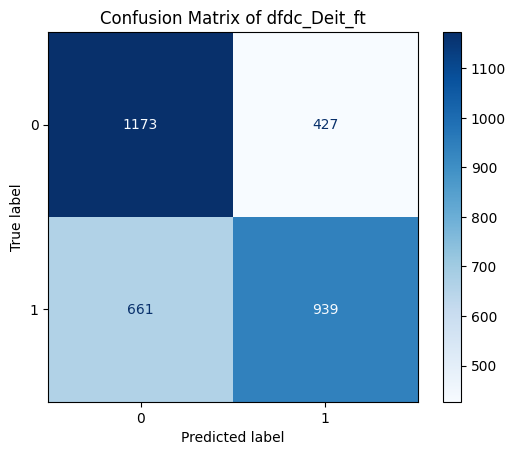

In [50]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ensure X_val_preprocessed has the correct shape if necessary
# X_val_preprocessed = np.transpose(X_val_preprocessed, (0, 3, 1, 2))  # If needed

# Generate predictions
y_pred = model.predict(X_test_preprocessed)
y_pred_classes = np.array(list(map(lambda x: 0 if x <= 0.5 else 1, y_pred)))

# Ensure y_val has the correct shape
y_true = y_test

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix 
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix of {model_name}')
file_name = f'{model_name}_Confusion_graph.png'
plt.savefig(file_name, dpi=1000, bbox_inches='tight')
print(f'Plot saved as {file_name}')
plt.show()


Plot saved as dfdc_Deit_ft_ROC_graph.png


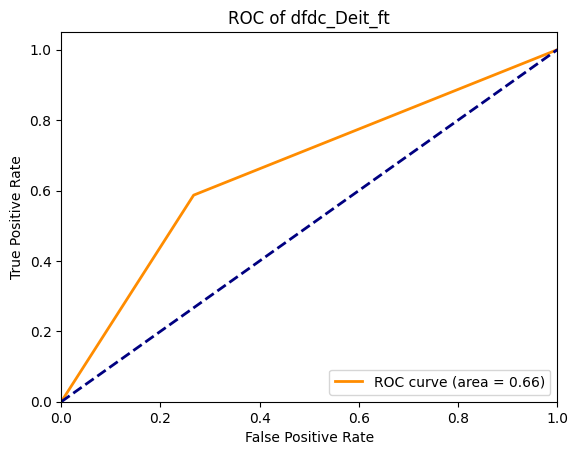

In [51]:
from sklearn.metrics import roc_curve, auc

# Assuming binary classification
fpr, tpr, thresholds = roc_curve(y_true, y_pred_classes)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC of {model_name}')
plt.legend(loc="lower right")

file_name = f'{model_name}_ROC_graph.png'
plt.savefig(file_name, dpi=1000, bbox_inches='tight')
print(f'Plot saved as {file_name}')
    
plt.show()


In [29]:
print("flops : ",flops)
print("macs : ",macs)

flops :  35436078917
macs :  17718039458


In [10]:

model = tf.keras.models.load_model("/kaggle/input/deepfake_models/keras/deepfake_models/6/dfdc_deit_ft.h5")

# Results

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix, cohen_kappa_score
import tensorflow as tf

def Results(model, test_set):
    # Evaluate the model
    results = model.evaluate(test_set)
    print("Evaluation results: ", results)

    y_true = []
    y_pred_probs = []

    print("Loading....", end="", flush=True)

    for images, labels in test_set:
        y_true.extend(labels.numpy())
        y_pred_probs.extend(model.predict(images, verbose=0).flatten())

    y_true = tf.convert_to_tensor(y_true)
    y_pred_probs = tf.convert_to_tensor(y_pred_probs)
    y_pred = (y_pred_probs > 0.5).numpy().astype("int32")

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=1)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_probs)
    prc_auc = average_precision_score(y_true, y_pred_probs)
    conf_matrix = confusion_matrix(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    tn, fp, fn, tp = conf_matrix.ravel()
    npv = tn / (tn + fn)

    print(f"Accuracy: {acc}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    print(f"ROC AUC: {roc_auc}")
    print(f"PRC AUC: {prc_auc}")
    print(f"Confusion Matrix: \n{conf_matrix}")
    print(f"Kappa Coefficient: {kappa}")
    print(f"NPV: {npv}")


# history_data

In [12]:


def history_data(history, file_name ):
    epoch_data = {
        'epoch': list(range(len(history.history['accuracy']) )),
        'accuracy': history.history['accuracy'],
        'loss': history.history['loss'],
        'val_accuracy': history.history['val_accuracy'],
        'val_loss': history.history['val_loss']
    }

    # Create DataFrame
    df = pd.DataFrame(epoch_data)

    # Save DataFrame to CSV
    
    df.to_csv(file_name, index=False)

    # Return DataFrame if needed
    return df




# Graph

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_combined_history(csv_path1, csv_path2, save=False):
    model1_name= csv_path1.split(sep='/')[-1][5:-4]
    model2_name=csv_path2.split(sep='/')[-1][5:-4]
    # Load the history from CSV files
    model1_history = pd.read_csv(csv_path1)
    model2_history = pd.read_csv(csv_path2)
    
    # Plot accuracy
    plt.figure(figsize=(16, 8))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(model1_history['epoch']+1, model1_history['accuracy'],'b--', label=f'{model1_name} Train Accuracy')
    plt.plot(model1_history['epoch']+1, model1_history['val_accuracy'],'r-', label=f'{model1_name} Validation Accuracy')
    plt.plot(model2_history['epoch']+1, model2_history['accuracy'],'c--', label=f'{model2_name} Train Accuracy')
    plt.plot(model2_history['epoch']+1, model2_history['val_accuracy'],'g-', label=f'{model2_name} Validation Accuracy')
    plt.title(f'{model1_name} vs {model2_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='upper left', bbox_to_anchor=(0.5, -0.1), ncol=1)  # Vertical columns for legend

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(model1_history['epoch']+1, model1_history['loss'], 'b--',label=f'{model1_name} Train Loss')
    plt.plot(model1_history['epoch']+1, model1_history['val_loss'], 'r-', label=f'{model1_name} Validation Loss')
    plt.plot(model2_history['epoch']+1, model2_history['loss'],'c--', label=f'{model2_name} Train Loss')
    plt.plot(model2_history['epoch']+1, model2_history['val_loss'],'g-', label=f'{model2_name} Validation Loss')
    plt.title(f'{model1_name} vs {model2_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper left', bbox_to_anchor=(0.5, -0.1), ncol=1)  # Vertical columns for legend

    # Adjust layout to make room for the legend
    plt.tight_layout()

    # Save the figure if save is True
    if save:
        file_name = f'{model1_name}_vs_{model2_name}.png'
        plt.savefig(file_name, dpi=300, bbox_inches='tight')
        print(f'Plot saved as {file_name}')
    
    # Show the plot
    plt.show()


In [35]:
model.load_weights("/kaggle/working/dfdc_swin_ft_weights.h5")

In [36]:
model_name = "dfdc_swin_ft"

CNN

In [17]:
# #CNN Networks
# y_true = []
# y_pred_probs = []
# X_test = []

# for images, labels in test_set:
#     X_test.extend(images.numpy())
#     y_true.extend(labels.numpy())
#     y_pred_probs.extend(model.predict(images, verbose=0).flatten())

# y_true = tf.convert_to_tensor(y_true).numpy().astype("int32")
# y_pred_probs = tf.convert_to_tensor(y_pred_probs)
# y_pred = (y_pred_probs > 0.5).numpy().astype("int32")
# print('Done')

Transformer

In [37]:
y_true = []
y_pred_probs = []
X_test = []

# Assuming X_test_preprocessed is a DataLoader or a dataset object with batches
for images, labels in test_dataset:
    X_test.extend(images.numpy())  # Collect test images
    y_true.extend(labels.numpy())  # Collect true labels
    
    y_pred_probs.extend(model.predict(images, verbose=0).flatten())  # Predict probabilities


# Convert to tensors and cast to desired types
y_true = tf.convert_to_tensor(y_true).numpy().astype("int32") 
y_pred_probs = tf.convert_to_tensor(y_pred_probs)
y_pred = (y_pred_probs > 0.5).numpy().astype("int32")  # Convert probabilities to binary predictions

print(model_name+' :Done')


dfdc_swin_ft :Done


In [29]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, roc_auc_score, average_precision_score

import numpy as np
import pandas as pd


# Calculate metrics
fpr, tpr, _ = roc_curve(y_true, y_pred)
precision, recall, _ = precision_recall_curve(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred_probs)
avg_precision = average_precision_score(y_true, y_pred_probs)

# Create a DataFrame with the metrics
metrics_df = pd.DataFrame({
    'FPR': np.concatenate([fpr, np.full_like(np.zeros(len(precision) - len(fpr)), np.nan)]),
    'TPR': np.concatenate([tpr, np.full_like(np.zeros(len(precision) - len(tpr)), np.nan)]),
    'Precision': np.concatenate([precision, np.full_like(np.zeros(len(fpr) - len(precision)), np.nan)]),
    'Recall': np.concatenate([recall, np.full_like(np.zeros(len(fpr) - len(recall)), np.nan)]),
    'ROC_AUC': [roc_auc] * len(fpr),
    'Average_Precision': [avg_precision] * len(precision)
})

save =True
# Save to CSV if save is True
if save:
    file_name = f'{model_name}_metrics.csv'
    metrics_df.to_csv(file_name, index=False)
    print(f'Metrics saved as {file_name}')
else:
    print('Metrics not saved.')


# Example usage with your existing data


metrics_df


Metrics saved as dfdc_swin_ft_metrics.csv


,FPR,TPR,Precision,Recall,ROC_AUC,Average_Precision
0,0.000000,0.000000,0.500000,1.000000,0.658537,0.654664
1,0.151875,0.351875,0.698511,0.351875,0.658537,0.654664
2,1.000000,1.000000,1.000000,0.000000,0.658537,0.654664


Plot saved as dfdc_swin_ft_ROC_graph.png


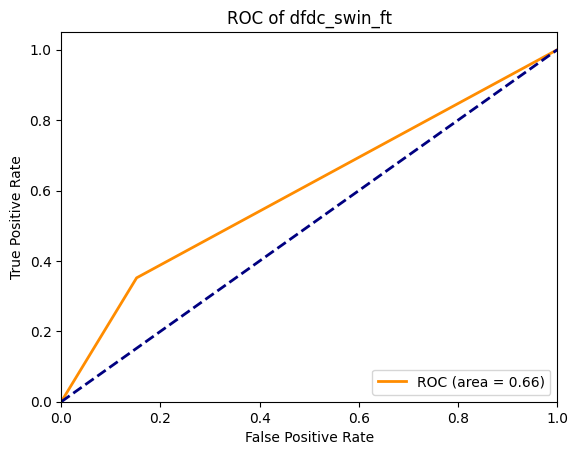

In [30]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
# Assuming binary classification
fpr, tpr = metrics_df['FPR'], metrics_df['TPR']
roc_auc = metrics_df['ROC_AUC'][0]

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC of {model_name}')
plt.legend(loc="lower right")

file_name = f'{model_name}_ROC_graph.png'
plt.savefig(file_name, dpi=1000, bbox_inches='tight')
print(f'Plot saved as {file_name}')
    
plt.show()


Plot saved as dfdc_swin_ft_PR_graph.png


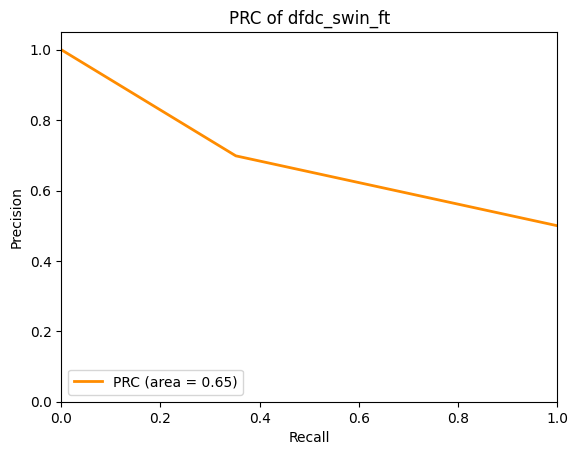

In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Assuming binary classification
precision, recall =  metrics_df['Precision'], metrics_df['Recall']
average_precision = metrics_df['Average_Precision'][0]

plt.figure()
plt.plot(recall, precision, color='darkorange', lw=2, label='PRC (area = %0.2f)' % average_precision)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'PRC of {model_name}')
plt.legend(loc="lower left")

file_name_pr = f'{model_name}_PR_graph.png'
plt.savefig(file_name_pr, dpi=1000, bbox_inches='tight')
print(f'Plot saved as {file_name_pr}')

plt.show()

Plot saved as dfdc_swin_ft_Confusion_graph.png


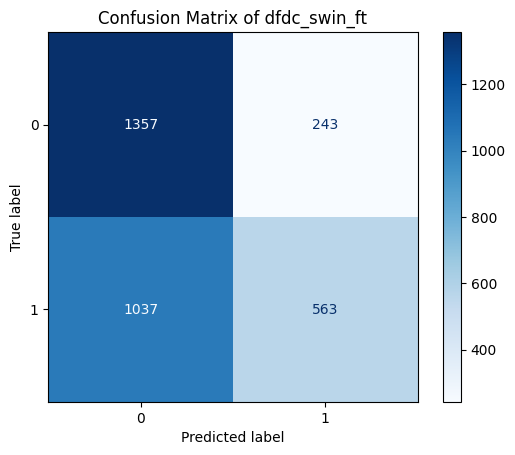

In [33]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix of {model_name}')
file_name = f'{model_name}_Confusion_graph.png'
plt.savefig(file_name, dpi=1000, bbox_inches='tight')
print(f'Plot saved as {file_name}')
plt.show()


Confusion mtrix